# UFO Sightings vs Population Density Analysis

This notebook analyzes the relationship between population density and UFO sightings using:
- `apportionment.csv` (population & density by state/year)
- `complete.txt` (UFO sightings highlights)


In [15]:
from pathlib import Path

def resolve_data_path(file_name: str) -> Path:
    candidates = [
        Path(file_name),
        Path.cwd() / file_name,
        Path.cwd() / "data" / file_name,
        *[(Path.cwd().parents[i] / "data" / file_name) for i in range(min(3, len(Path.cwd().parents)))]
    ]
    for p in candidates:
        if p.is_file():
            print(f"Using: {p}")
            return p
    raise FileNotFoundError(f"Could not find {file_name}. Move it to a 'data/' folder or provide absolute path.")

APPORTIONMENT = resolve_data_path("apportionment.csv")
UFO_HIGHLIGHTS = resolve_data_path("complete.txt")

Using: apportionment.csv
Using: complete.txt


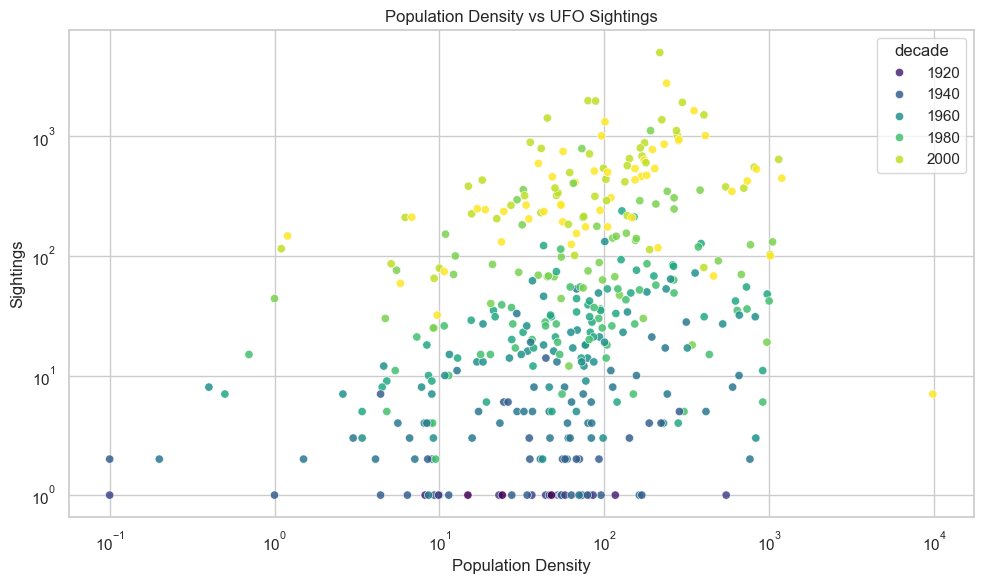

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))
sns.scatterplot(data=merged, x="Density", y="Sightings", hue="decade", palette="viridis", alpha=0.85)
plt.xscale("log"); plt.yscale("log")
plt.title("Population Density vs UFO Sightings")
plt.xlabel("Population Density")
plt.ylabel("Sightings")
plt.tight_layout()
plt.show()

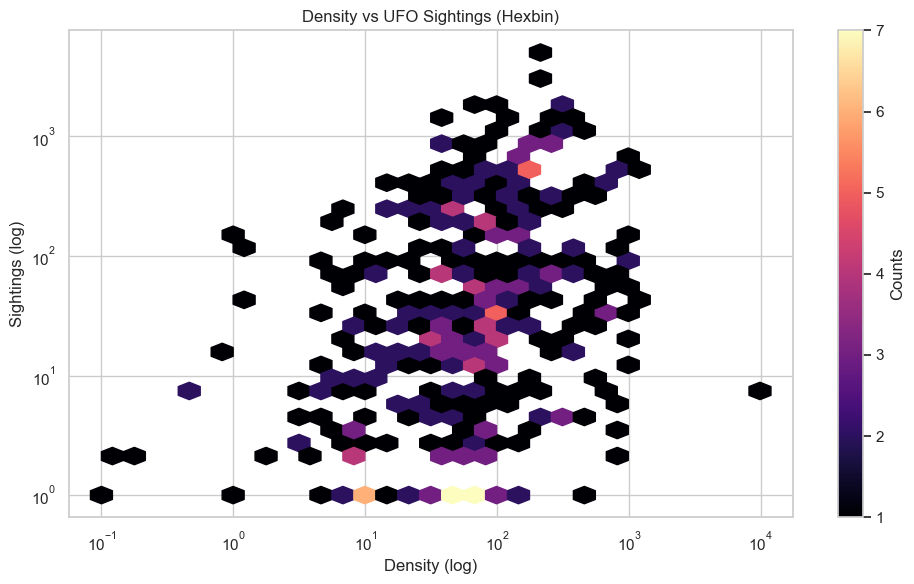

In [17]:
plt.figure(figsize=(10,6))
hb = plt.hexbin(merged["Density"], merged["Sightings"], gridsize=30, cmap="magma", xscale="log", yscale="log", mincnt=1)
plt.colorbar(hb, label="Counts")
plt.title("Density vs UFO Sightings (Hexbin)")
plt.xlabel("Density (log)")
plt.ylabel("Sightings (log)")
plt.tight_layout()
plt.show()

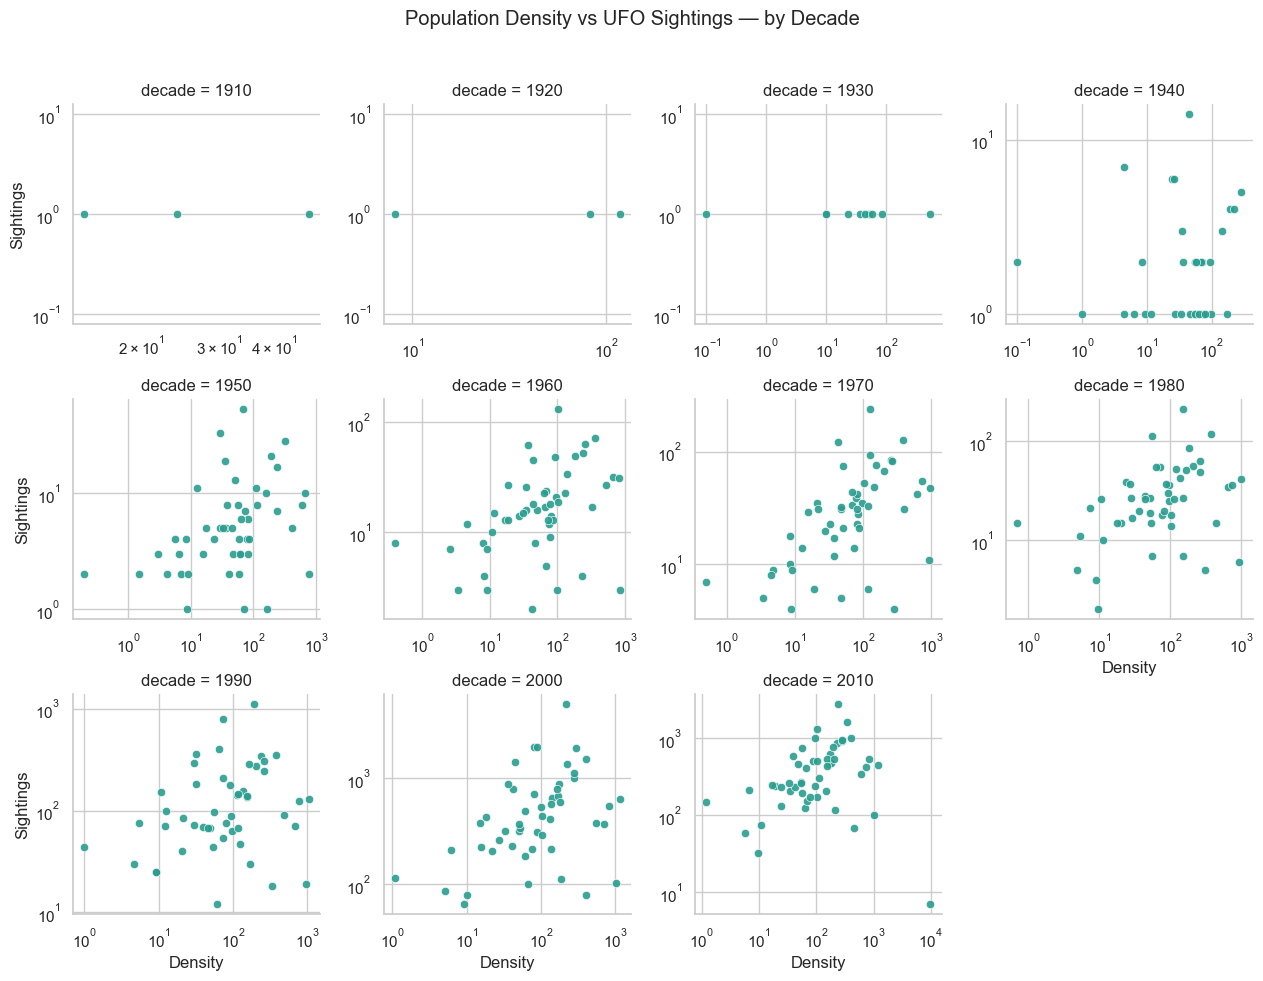

In [18]:
g = sns.FacetGrid(merged, col="decade", col_wrap=4, sharex=False, sharey=False, height=3.2)
g.map_dataframe(sns.scatterplot, x="Density", y="Sightings", alpha=0.9, color="#2a9d8f")
for ax in g.axes.flatten():
    ax.set_xscale("log"); ax.set_yscale("log")
g.fig.suptitle("Population Density vs UFO Sightings — by Decade", y=1.02)
plt.tight_layout()
plt.show()